In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("C:\\Users\\LENOVO\\Desktop\\LSRA\\Data_cleaning\\kaggle_merged\\merged_music_dataset.csv")
# Define the subset of emotion classes you want to keep
selected_classes = ["anger", "fear", "romantic", "sadness"]

# Filter the DataFrame to include only those classes
df_subset = df[df["final_emotion"].isin(selected_classes)]


In [9]:
balanced_df = (
    df_subset.groupby('final_emotion', group_keys=False)
      # .apply(lambda x: x.sample(2500, random_state=42))
      .apply(lambda x: x.sample(1250, random_state=42))
      # .apply(lambda x: x.sample(1667, random_state=42))
      .reset_index(drop=True)
)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_42024\1470045742.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(1250, random_state=42))


In [10]:
balanced_df['final_emotion'].value_counts()


final_emotion
anger       1250
fear        1250
romantic    1250
sadness     1250
Name: count, dtype: int64

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    balanced_df['cleaned_lyrics'],
    balanced_df['final_emotion'],
    test_size=0.2,
    stratify=balanced_df['final_emotion'],
    random_state=42
)

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = LinearSVC()
model.fit(X_train_vec, y_train)
y_pred = model.predict(X_test_vec)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

       anger       0.48      0.48      0.48       250
        fear       0.39      0.40      0.40       250
    romantic       0.46      0.48      0.47       250
     sadness       0.40      0.38      0.39       250

    accuracy                           0.43      1000
   macro avg       0.43      0.43      0.43      1000
weighted avg       0.43      0.43      0.43      1000



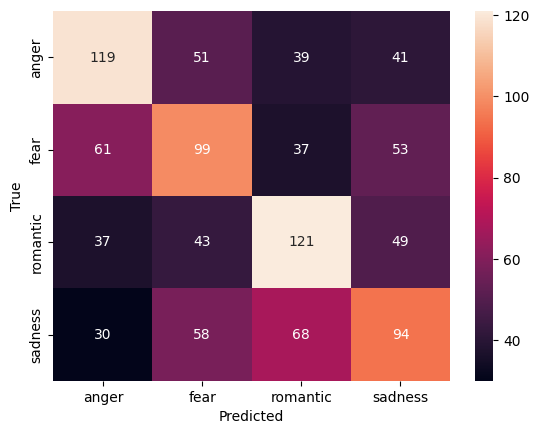

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
